In [243]:
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, make_scorer,
                             classification_report, confusion_matrix)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Reshape, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import mannwhitneyu, spearmanr, ks_2samp
from scipy import stats
from statsmodels.stats.multitest import multipletests
import sdv
from scipy.stats import spearmanr
from sklearn.neighbors import KNeighborsClassifier

# Généralité

* Dans un premier temps nous comptons simplifier le dataset initial en supprimant les variables avec une forte proportion de 0 car elles sont peu informatives; supprimer l'une des variables dans les couples de variables trop correlées car elles fournissent quasiment les mêmes informations et enfin garder uniquement les variables les plus importante en utilisant SlectKBest et RandomForest

* Dans un second temps, on va créer nos données d'entrainements et nos données de test avec une proportion de 30% pour nos données de test

* Dans un troisième temps, on va générer nos 3 datasets résultants des trois algorithmes, sur la base du dataset d'entrainement. On choisira le nombre de lignes de sorte à ce que les données de test représentent 20% des données d'entrainement obtenues après augmentation; cela permet de ne pas avoir un nombre important de données d'entrainement devant le nombre de données de test

* Les raisons qui nous ont poussées à proceder comme ça sont les suivantes :
  - Les 4 datasets seront testés sur les même données de test, ce qui garantit une procédure de test non biaisée et plus partiale
  - On a enlevé les variables initules avant de générer nos 3 datasets car ces variables allaient juste nous encombrer , du fait qu'elles n'apportent pas réellement une quatité d'information assez conséquante

# Fonctionc utiles pour plus tard

# CHOIX DES METRIQUES

Accuracy Recall Precision F1-score AUC

Il est important de noter que le recall est le paramètre le plus important dans ce cadre de classification de Ransomwares et Goodwares. En effet maximiser le Recall reviendrait à miniser le nombre de Faux Négatif, ce qui se traduit par minimiser le nombre de Ransomware détecté comme Goodware; en effet c'est mieux de détecter un Goodware comme Ransomware que de détecter un Ransomware comme Goodware

In [244]:
def complete_with_tvae(df, n_additional_samples=500, epochs=500):
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df)
    model = TVAESynthesizer(metadata, epochs=epochs)
    model.fit(df)
    print(f"Génération de {n_additional_samples} nouvelles lignes...")
    synthetic_samples = model.sample(num_rows=n_additional_samples)
    augmented_df = pd.concat([df, synthetic_samples], ignore_index=True)
    return augmented_df


Cette fonction permet de générer un nouveau dataframe qui est le dataframe originel , complété par des lignes fictives crées par l'algorithme CTGAN

In [245]:
def complete_with_ctgan(df, n_additional_samples=500, epochs=500):
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df)
    model = CTGANSynthesizer(metadata, epochs=epochs)
    model.fit(df)
    synthetic_samples = model.sample(num_rows=n_additional_samples)
    augmented_df = pd.concat([df, synthetic_samples], ignore_index=True)
    return augmented_df


Cette fonction permet de générer un nouveau dataframe qui est le dataframe originel , complété par des lignes fictives crées par l'algorithme CTGAN

In [246]:
def supprimer_features_correlees(df, target_col='Label', target_val='Ransomware', seuil=0.9, plot=True, method='spearman'):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    y_encoded = (y == target_val).astype(int) 

    corr_matrix = X.corr(method=method)

    if plot:
        plt.figure(figsize=(20, 16))
        sns.heatmap(corr_matrix, annot=False, cmap='coolwarm',
                    center=0, square=True, linewidths=0.5)
        plt.title(f"Matrice de corrélation ({method}) des features (seuil={seuil})")
        plt.tight_layout()
        plt.show()

    triangle_sup = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    paires_correlees = (
        triangle_sup.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    )

    paires_correlees = paires_correlees[
        paires_correlees['correlation'].abs() >= seuil
    ].sort_values('correlation', ascending=False)
    print(f"Nombre de paires fortement corrélées : {len(paires_correlees)}")

    if method == 'spearman':
        corr_avec_label = X.apply(
            lambda col: spearmanr(col, y_encoded)[0]
        ).abs()
    else:
        corr_avec_label = X.corrwith(y_encoded).abs()

    to_drop = set()
    for _, row in paires_correlees.iterrows():
        f1, f2 = row['feature_1'], row['feature_2']
        if f1 in to_drop or f2 in to_drop:
            continue
        c1 = corr_avec_label.get(f1, 0)
        c2 = corr_avec_label.get(f2, 0)
        a_garder    = f1 if c1 >= c2 else f2
        a_supprimer = f2 if c1 >= c2 else f1
        print(f"  Paire ({f1} / {f2}) → garder {a_garder} ({max(c1,c2):.3f}), supprimer {a_supprimer} ({min(c1,c2):.3f})")
        to_drop.add(a_supprimer)

    cols_supprimees = [c for c in to_drop if c in df.columns]
    df_clean = df.drop(columns=cols_supprimees).copy() 


    df_clean[target_col] = df[target_col].values
    df_clean = df_clean.reset_index(drop=True)
    return df_clean

Cette fonction permet de supprimer une variable dans les paires de variables trop correlées. Dans le cas où 2 variables sont très correlées, on garde celle qui a une meilleure correlation avec le target en utilisant la méthode spearman qui n'est pas sensible aux outliers contrairement à une comparaison simple des valeurs brutes.

In [247]:
def corriger_valeurs_negatives(df_ds, target_col='Label', verbose=True):
    
    feature_cols_loc = [c for c in df_ds.columns if c != target_col]
    df_corr = df_ds.copy()

    nb_negatifs_avant = (df_corr[feature_cols_loc] < 0).sum().sum()

    if verbose:
        if nb_negatifs_avant > 0:
            cols_neg = df_corr[feature_cols_loc].columns[
                (df_corr[feature_cols_loc] < 0).any()
            ].tolist()
    df_corr[feature_cols_loc] = df_corr[feature_cols_loc].clip(lower=0)

    nb_negatifs_apres = (df_corr[feature_cols_loc] < 0).sum().sum()
    return df_corr

Cette fonction remplace toutes les valeurs négatives des colonnes dans les datasets généreés par 0.
Les données sont des comptages d'appels système, donc forcément positif ou nul.

In [248]:
def verifier_equilibre(datasets: dict, target_col='Label'):
    records = []

    for nom, df_ds in datasets.items():
        total  = len(df_ds)
        counts = df_ds[target_col].value_counts()
        classes = counts.index.tolist()

        for cls in classes:
            pct = counts[cls] / total * 100
            records.append({'Dataset': nom, 'Classe': str(cls),
                            'Nombre': counts[cls], 'Pourcentage (%)': round(pct, 2)})

        pcts  = (counts / total * 100).values
        ecart = pcts.max() - pcts.min()

        status = " équilibré" if ecart <= 10 else "  déséquilibré"
        print(f"\n  {nom} ({total} lignes) — {status} (écart = {ecart:.1f} pts)")
        for cls in classes:
            print(f"    {str(cls):>15} : {counts[cls]:>5} lignes  ({counts[cls]/total*100:.1f} %)")

    print()

    # Graphique comparatif
    df_eq    = pd.DataFrame(records)
    ds_names = df_eq['Dataset'].unique()
    classes  = df_eq['Classe'].unique()
    x        = np.arange(len(ds_names))
    width    = 0.35
    colors   = ['steelblue', 'tomato']

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, cls in enumerate(classes):
        vals = [df_eq[(df_eq['Dataset'] == ds) & (df_eq['Classe'] == str(cls))]['Pourcentage (%)'].values[0]
                for ds in ds_names]
        ax.bar(x + i * width, vals, width, label=str(cls), color=colors[i % len(colors)], alpha=0.85)

    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='50 %')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(ds_names)
    ax.set_ylabel("Proportion (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Répartition des classes par dataset")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return df_eq

Cette fonction permet de vérifier que les datasets générées gardent la propriété d'équilibre du dataset original

In [249]:
def features_selection(dataset, target_col='Label', test_size=0.2, verbose=True):
    if target_col not in dataset.columns:
        raise ValueError(f"La colonne cible '{target_col}' n'existe pas dans le dataset")

    X = dataset.drop(columns=[target_col])
    y = dataset[target_col]

    if not isinstance(X, pd.DataFrame):
        raise ValueError("X doit être un DataFrame pandas avec des noms de colonnes")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=0, stratify=y
    )

    label_mapping = {'Goodware': 0, 'Ransomware': 1}

    if isinstance(y_train, pd.Series) and y_train.dtype == 'object':
        y_train_enc = y_train.map(label_mapping)
    else:
        y_train_enc = y_train
        
    if isinstance(y_test, pd.Series) and y_test.dtype == 'object':
        y_test_enc = y_test.map(label_mapping)
    else:
        y_test_enc = y_test


    scorer = make_scorer(recall_score, pos_label=1)

    pipeline = make_pipeline(
        PolynomialFeatures(include_bias=False, interaction_only=True),
        SelectKBest(f_classif),
        RandomForestClassifier(random_state=0, class_weight='balanced')
    )

    param_grid = {
        'polynomialfeatures__degree': [1, 2],
        'selectkbest__k': list(range(25, int(df_new.shape[1]))),
        'randomforestclassifier__n_estimators': [100, 200],
        'randomforestclassifier__max_depth': [None, 10, 20],

    }


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=cv, scoring=scorer,
        n_jobs=-1, verbose=1 if verbose else 0
    )
    grid_search.fit(X_train, y_train_enc)

    best_pipeline = grid_search.best_estimator_
    best_params   = grid_search.best_params_
    best_cv_score = grid_search.best_score_

    if verbose:
        print(f"\n Meilleurs paramètres : {best_params}")
        print(f" Meilleur Recall (CV) : {best_cv_score:.4f}")


    poly_step = best_pipeline.named_steps['polynomialfeatures']
    selector  = best_pipeline.named_steps['selectkbest']

    poly_feature_names = poly_step.get_feature_names_out(X_train.columns)
    support            = selector.get_support()
    selected_features  = poly_feature_names[support].tolist()

    if verbose:
        print(f"\n Nombre de features sélectionnées : {len(selected_features)}")


    X_poly_full = pd.DataFrame(
        poly_step.transform(X),
        columns=poly_feature_names,
        index=X.index
    )
    X_selected_full = X_poly_full[selected_features].copy()

    if verbose:
        y_proba = best_pipeline.predict_proba(X_test)[:, 1]
        print("\n Recall vs Precision selon le seuil ")

        for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
            y_pred_bin = (y_proba >= threshold).astype(int)
            recall    = recall_score(y_test_enc, y_pred_bin, pos_label=1)
            precision = precision_score(y_test_enc, y_pred_bin, pos_label=1)
            print(f"  Seuil {threshold:.1f} → Recall={recall:.3f}  Precision={precision:.3f}")

        seuil_optimal  = 0.3
        y_pred_final   = (y_proba >= seuil_optimal).astype(int)

        print(f"\n Rapport final (seuil={seuil_optimal})")
        print(classification_report(y_test_enc, y_pred_final, target_names=['Goodware', 'Ransomware']))
        print("Matrice de confusion :")
        print(confusion_matrix(y_test_enc, y_pred_final))

    y_enc_full = y.map(label_mapping) if y.dtype == 'object' else y
    y_enc_full.index = X.index


    final_dataset = X_selected_full.copy()
    final_dataset[target_col] = y_enc_full.values

    if verbose:
        print(f"\n Dataset final : {final_dataset.shape[0]} lignes × {final_dataset.shape[1]} colonnes")

    return final_dataset

Cette fonction permet de faire une sélection des features par évaluation du SelectKBest et du RandomForestClassifier. On a cherché à maximiser le Recall, ce qui traduis un nombre de Faux-Negatif faible, en effet c'est mieux de classer un Goodware en tant que Ransomware, plutôt que de classer un Ransomware comme un Goodware

# EDA

On charge le dataset fournis, duquel on construit 2 datasets, un pour les Goodware et l'autre pour les Ransomwares

In [250]:
path = r'C:\Users\HP\Downloads\file.csv'
data = pd.read_csv(path)
df = pd.DataFrame(data)

In [251]:
df.shape

(806, 65)

In [252]:
df = df.drop_duplicates()
Goodware_df = df[df['Label'] == 'Goodware'].drop(columns=['Label'])
Ransomware_df = df[df['Label'] == 'Ransomware'].drop(columns=['Label'])
df.shape

(588, 65)

# Taille du dataset, types des variables et proportions de valeurs nulles

On trouve des caractéristiques de notre dataset

In [253]:
print(Goodware_df.shape[0])
Ransomware_df.shape[0]

315


273

On a une proportion de 53.6% de Goodware et de 46.4% de Ransomware, ce qui nous permet de conclure qu'on a un dataset équilibré

In [254]:
print('la taille du dataset est: ' + str(df.shape[0]) + ' lignes et '+ str(df.shape[1]) + " colonnes")
print("Le dataset est composé de features du type :\n")
print(df.dtypes.value_counts())
print("Le pourcentage de valeurs nulles est  "+ str((df == 0).sum().sum()/df.size) + " du Dataset en entier")

la taille du dataset est: 588 lignes et 65 colonnes
Le dataset est composé de features du type :

int64     64
object     1
Name: count, dtype: int64
Le pourcentage de valeurs nulles est  0.5510204081632653 du Dataset en entier


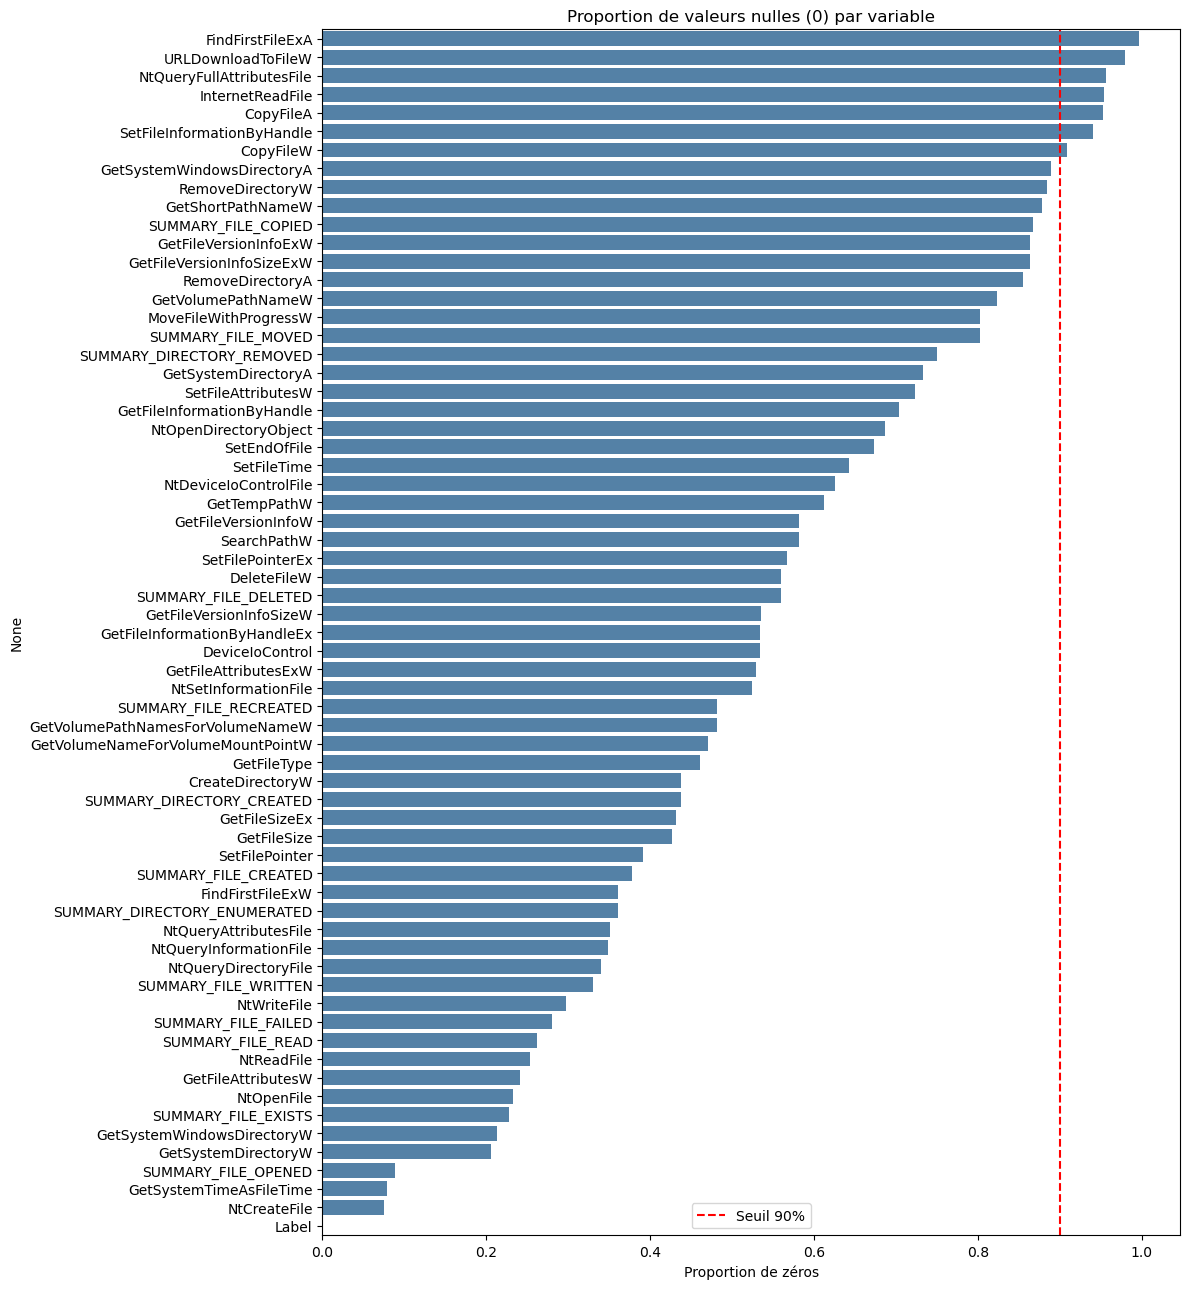

In [255]:
zero_ratio = (df == 0).sum() / df.shape[0]
zero_ratio = zero_ratio.sort_values(ascending=False)

plt.figure(figsize=(12, len(zero_ratio) * 0.2))
sns.barplot(x=zero_ratio.values, y=zero_ratio.index, color='steelblue')
plt.axvline(x=0.9, color='red', linestyle='--', label='Seuil 90%')
plt.xlabel("Proportion de zéros")
plt.title("Proportion de valeurs nulles (0) par variable")
plt.legend()
plt.tight_layout()
plt.show()

Ici nous visualisons chaque colonne en fonction de son pourcentage de 0. On remarque que 7 variables ont plus de 90% de leurs valeurs qui sont nulles. On peut donc considérer qu'elles n'apportent pas assez d'information

On récupère donc ces variables à forte proportion de 0 dans une liste

In [256]:
quasinull_columns = df.columns[(df == 0).sum() / df.shape[0] > 0.9].tolist()
quasinull_columns

['CopyFileA',
 'CopyFileW',
 'InternetReadFile',
 'SetFileInformationByHandle',
 'URLDownloadToFileW',
 'FindFirstFileExA',
 'NtQueryFullAttributesFile']

<Axes: >

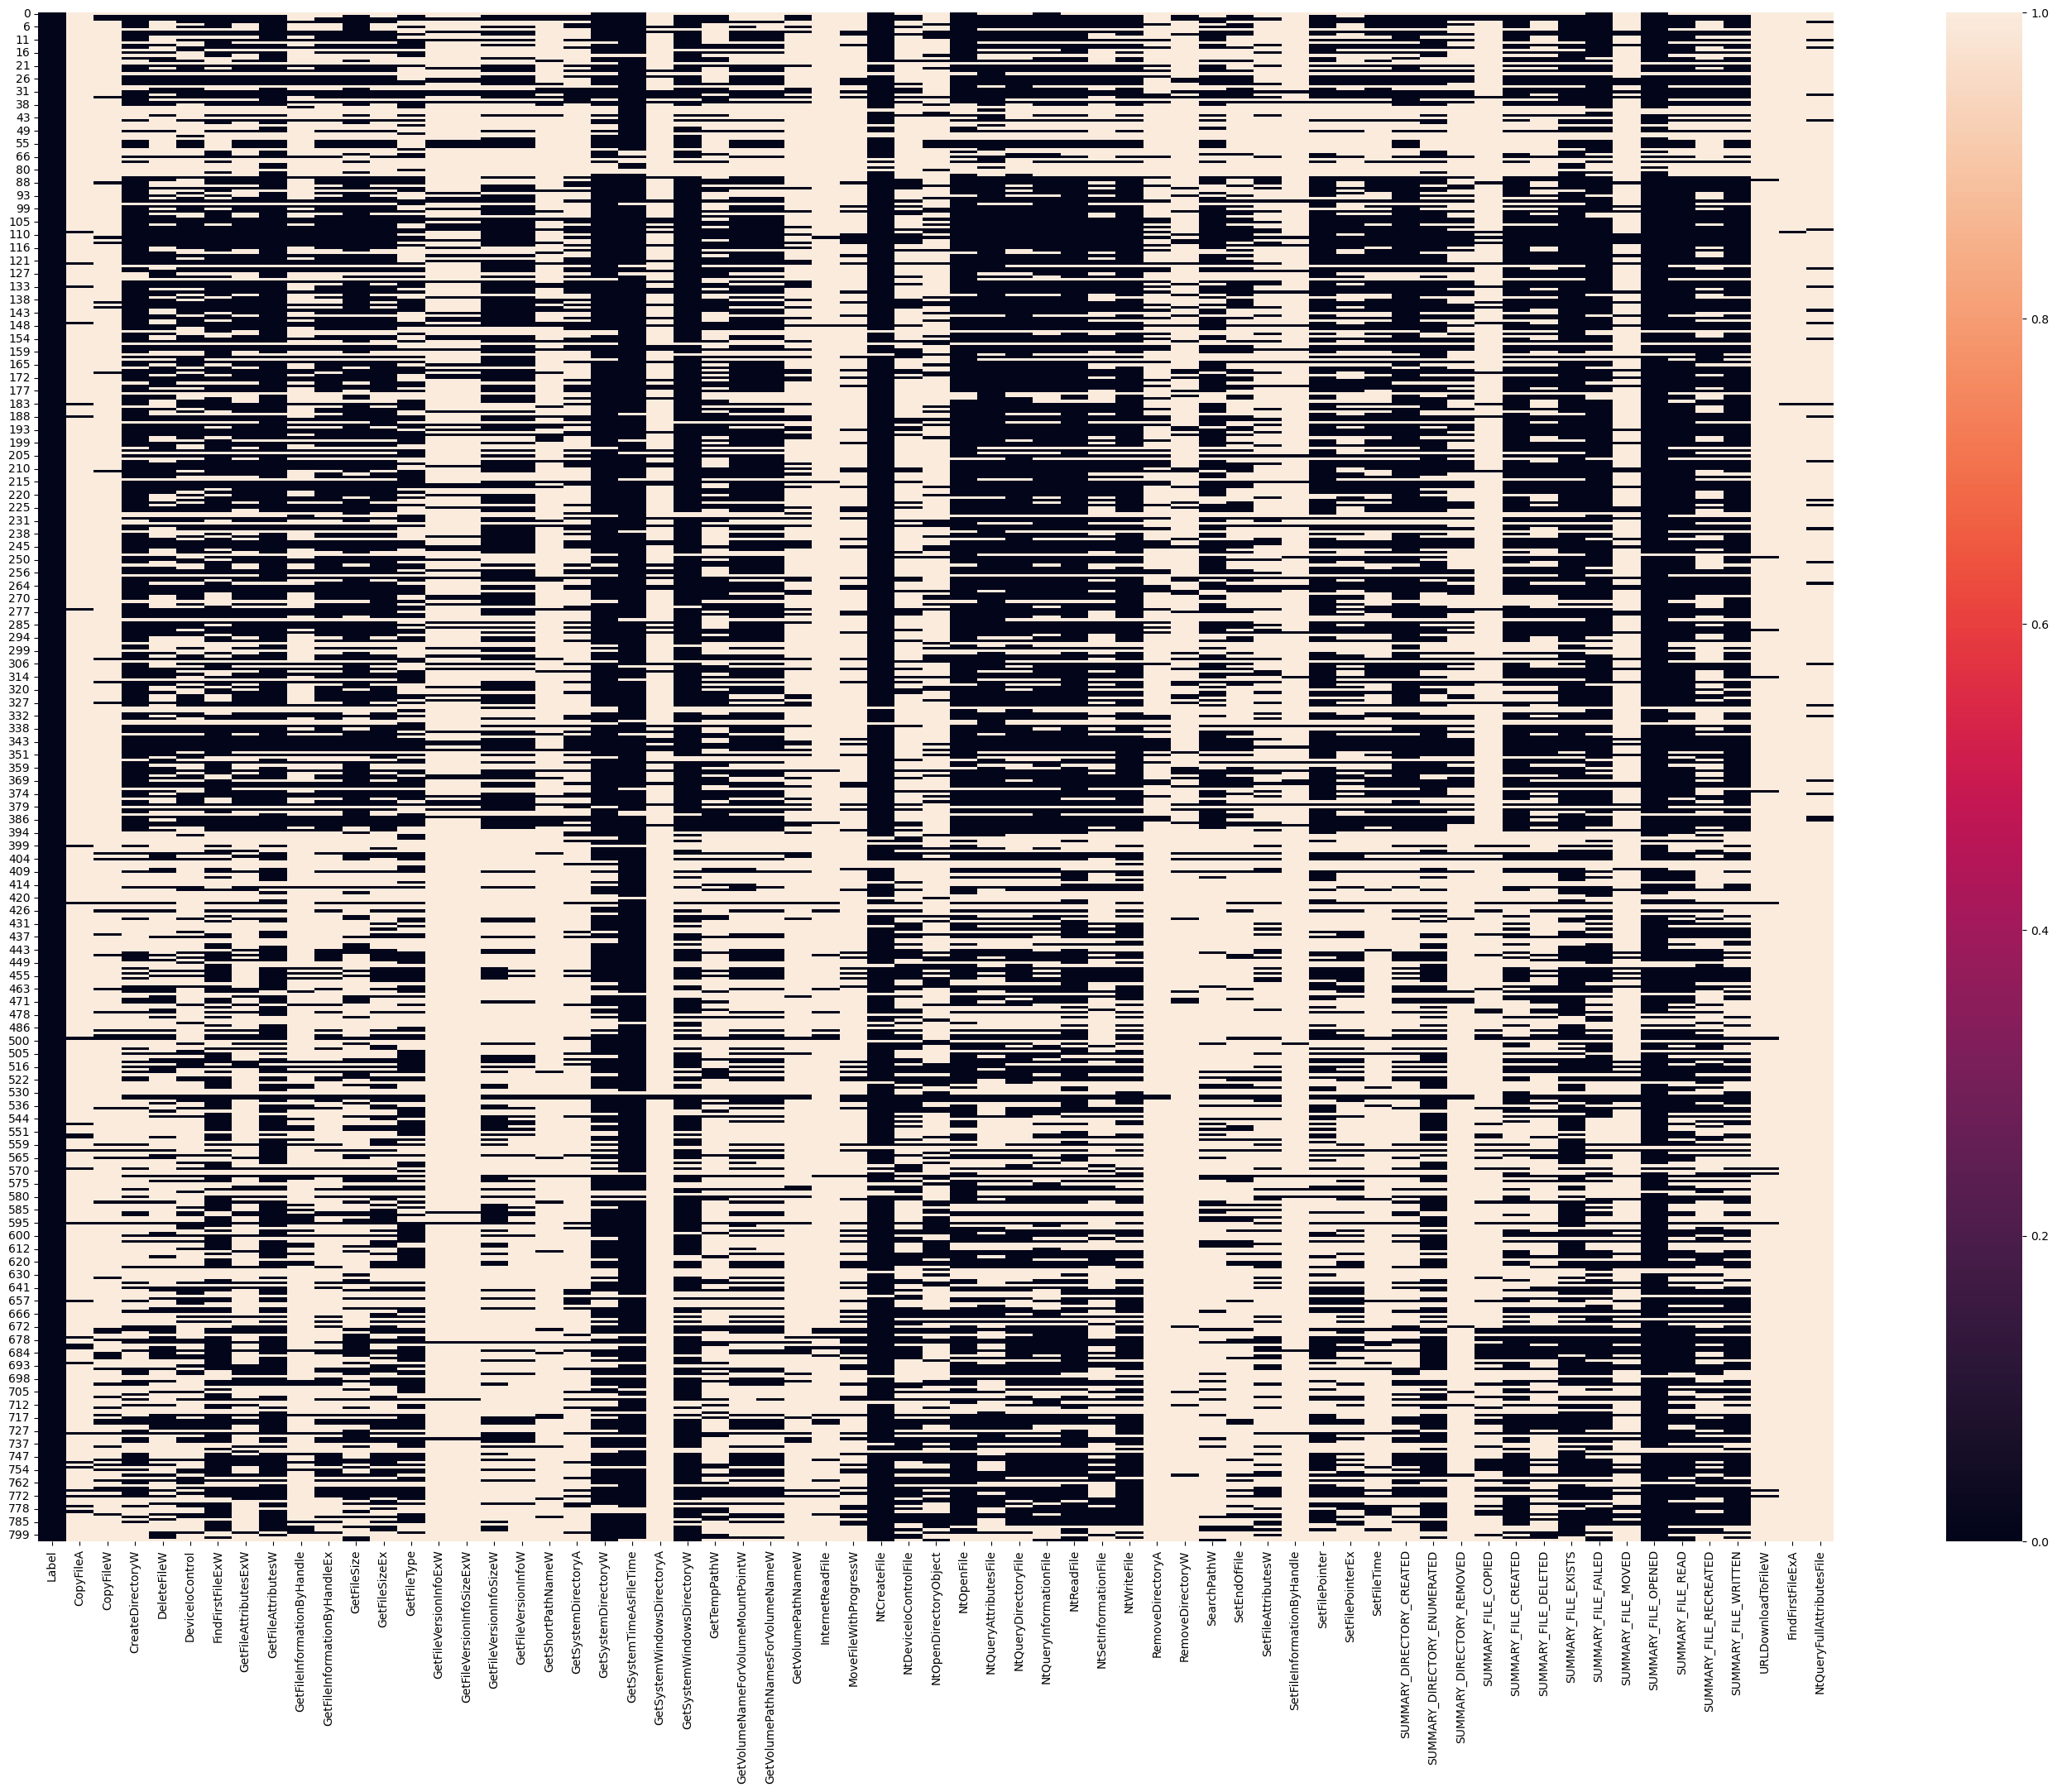

In [257]:
plt.figure(figsize=(35, 24))
sns.heatmap(df == 0)

Ce Graphe montre la repartition des valeurs nulles dans le dataset. On voit directement les variables qui toute leur colonne/bande qui est quasiment noir ce qui traduit un fort taux de valeurs nulles. Aussi les valeurs nulles sont présentes un peu partout dans le dataset, elles ne sont pas regroupées dans une zone

# Visualisation des caractéristiques de chaques variables

Ici, nous traçons des histogrammes pour chaque variable. Sur chaque histogramme, on peut voir combien de Ransomware et Goodware appèle ou utilise chaque variable, et combien de fois ils le font. Par exemple, on pourra dire que 205 Ransomwares n'utilisent jamais un fichier, 7 Ransomwares utilisent un fichier 4 fois , et 70 Goodwares utilisent ce fichiers 7 fois. 


La pertinence de ces histogrammes vient du fait qu'on peut, en les analysant, distinguer dans un premier temps les variables à fort pouvoir discriminant, c'est-à-dire qui sont souvent utilisées par un seul groupe d'application au détriment de l'autre, et dans un second temps les variables qui sont utilisées de manière équilibrée par les 2 groupes et qui sont donc inutiles car elles n'apportent pas vraiment d'informations qui permettent de distinguer les 2 groupes

In [258]:
output_pdf = r"C:/Users/HP/Documents/mon_analyse.pdf"

with PdfPages(output_pdf) as pdf:
    for i, col in enumerate(Goodware_df.columns, start=1):
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.histplot(np.log1p(Goodware_df[col]), label='Goodware', discrete=True, color='blue', kde=False, ax=ax)
        sns.histplot(np.log1p(Ransomware_df[col]), label='Ransomware', discrete=True, color='red', kde=False, ax=ax)
        ax.set_title(f"Distribution de {col} (Figure {i})")
        ax.legend()
        
        pdf.savefig(fig)
        plt.close(fig)

# Hypothèses émises après analyse des histogrammes

Au terme de l'analyse des histogrammes, on émet les hypothèses suivantes :

* DeleteFileW, NtSetInformationFile, SetEndOfFile, SetFileTime, NtWriteFile, NtReadFile, NtCreateFile, NtOpenFile, MoveFileWithProgressW, SetFileAttributesW, SUMMARY_FILE_WRITTEN, SUMMARY_FILE_MOVED, SUMMARY_FILE_DELETED sont plus sollicités par les Ransomwares
  
* CopyFileA, CopyFileW, InternetReadFile, URLDownloadToFileW, GetFileVersionInfoExW, GetFileVersionInfoSizeExW, NtQueryFullAttributesFile ont un faible pouvoir discriminant

  
* GetFileVersionInfoExW, GetFileVersionInfoSizeExW, GetFileVersionInfoSizeW, GetFileVersionInfoW, NtQueryFullAttributesFile, GetShortPathNameW sont plus sollicités par les Goodwares



# Test d'hypothèses

Dans cette section, nous allons tester les hypothèses émises plus haut avec des tests statistiques

##### Testons l'équilibre des variables retenues : Test U de Mann-Whitney + AUC

In [259]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

alpha = 0.05
results = []

for col in tested_list:
    if col not in Goodware_df.columns:
        continue
    groupe_goodware   = Goodware_df[col].dropna()
    groupe_ransomware = Ransomware_df[col].dropna()
    stat, p_value = mannwhitneyu(groupe_goodware, groupe_ransomware, alternative='two-sided')
    results.append({
        'feature' : col,
        'p_value' : round(float(p_value), 6),
    })

results_df = pd.DataFrame(results)
variables_equilibrees = results_df[results_df['p_value'] >= alpha]['feature'].tolist()
print(f"\nVariables équilibrées : {variables_equilibrees}")


Variables équilibrées : ['URLDownloadToFileW']


la variable URLDownloadToFileW apporte peu d'informations car elles sont autant sollicitées par les Goodwares que par les Ransomwares. On peut donc les éliminer

##### Testons la tendance pour un feature à être appelé par un Goodware ou un Ransomware: Test de Mann-Whitney U complété par le r de rang 

In [260]:
goodware_preferred = ['GetFileVersionInfoExW', 'GetFileVersionInfoSizeExW', 'GetFileVersionInfoSizeW', 'GetFileVersionInfoW', 'NtQueryFullAttributesFile', 'GetShortPathNameW']

ransomware_preferred = ['DeleteFileW', 'NtSetInformationFile', 'SetEndOfFile', 'SetFileTime', 'NtWriteFile', 'NtReadFile', 'NtCreateFile', 'NtOpenFile', 'MoveFileWithProgressW', 'SetFileAttributesW', 'SUMMARY_FILE_WRITTEN', 'SUMMARY_FILE_MOVED', 'SUMMARY_FILE_DELETED']

# Seuil 
ALPHA = 0.05

def confirmer_preferences(variable_list, goodware_df, ransomware_df,
                           variables_equilibrees, quasinull_columns,
                           alpha=0.05):
 
    resultats = []
 
    for var in variable_list:

        if var not in df.columns:
            continue

        if var in variables_equilibrees or var in quasinull_columns:
            continue
 
        g = Goodware_df[var].dropna().values
        r = Ransomware_df[var].dropna().values
 
        if len(g) < 2 or len(r) < 2:
            continue
 
#  Test Mann-Whitney U 
        U, p = stats.mannwhitneyu(g, r, alternative="two-sided")
 
        resultats.append({
            "variable": var,
            "p_value":  p,
            "med_g":    np.median(g),
            "med_r":    np.median(r),
        })
 
    if not resultats:
        print("Aucune variable testable.")
        return [], []
 
    res_df = pd.DataFrame(resultats)
 
#  Correction FDR 
    reject, p_adj, _, _ = multipletests(res_df["p_value"], alpha=alpha, method="fdr_bh")
    res_df["p_adj"]       = p_adj
    res_df["significant"] = reject
 
# Filtrage : uniquement les variables significatives 
    sig = res_df[res_df["significant"]]
 
# Séparation selon la direction
    confirmees_goodware   = sig[sig["med_g"] > sig["med_r"]]["variable"].tolist()
    confirmees_ransomware = sig[sig["med_r"] > sig["med_g"]]["variable"].tolist()
 
    return confirmees_goodware, confirmees_ransomware
 
 
# Lancement
 
g_confirmed, r_confirmed = confirmer_preferences(
    goodware_preferred + ransomware_preferred,
    Goodware_df, Ransomware_df,
    variables_equilibrees, quasinull_columns,
    alpha=ALPHA
)
 
print("Variables confirmées comme préférées par les GOODWARE :")
print(g_confirmed)
 
print("\nVariables confirmées comme préférées par les RANSOMWARE :")
print(r_confirmed)
 

Variables confirmées comme préférées par les GOODWARE :
['GetFileVersionInfoSizeW', 'GetFileVersionInfoW', 'DeleteFileW', 'NtSetInformationFile', 'SetFileTime', 'NtWriteFile', 'NtReadFile', 'NtCreateFile', 'NtOpenFile', 'SUMMARY_FILE_WRITTEN', 'SUMMARY_FILE_DELETED']

Variables confirmées comme préférées par les RANSOMWARE :
[]


Au termes de ces tests d'hypothèses, seule une variable s'est avérée être équilibrée dans son utilisation par les Goodwares et Ransomwares, c'est donc une variable peu informative; et 11 se sont avérées être beaucoup plus utilisées par les Goodwares, ce sont donc des variables très utiles pour la suite

In [261]:

variables_a_supprimer = variables_equilibrees + quasinull_columns
variables_a_garder = g_confirmed

df_new = df.drop(columns=[v for v in variables_a_supprimer if v in df.columns])

df_new.head()

,Label,CreateDirectoryW,DeleteFileW,DeviceIoControl,FindFirstFileExW,GetFileAttributesExW,GetFileAttributesW,GetFileInformationByHandle,GetFileInformationByHandleEx,GetFileSize,...,SUMMARY_FILE_COPIED,SUMMARY_FILE_CREATED,SUMMARY_FILE_DELETED,SUMMARY_FILE_EXISTS,SUMMARY_FILE_FAILED,SUMMARY_FILE_MOVED,SUMMARY_FILE_OPENED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,SUMMARY_FILE_WRITTEN
0,Goodware,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,2,0,0,0
1,Goodware,9,15,1,22,47,82,0,0,82,...,7,19,15,41,74,0,39,24,16,19
3,Goodware,19,22,23,30,58,314,0,52,377,...,7,20,21,110,83,0,216,71,16,21
4,Goodware,14,0,1,44,6,7,1,34,3,...,0,12,0,12,12,0,74,33,0,10
5,Goodware,43,0,0,15,0,4,0,0,352,...,0,30,0,3,36,0,346,2,0,17


In [262]:
print(df_new.shape)
(df_new == 0).sum().sum() / df.size

(588, 58)


np.float64(0.44814233385661956)

On remarque une diminution considérable du pourcentage de valeurs nulles qui passe de 55.01% à 44.8%

# Suppression des variables trop correlées , et aussi sur par SelectKBest couplé au randomForest

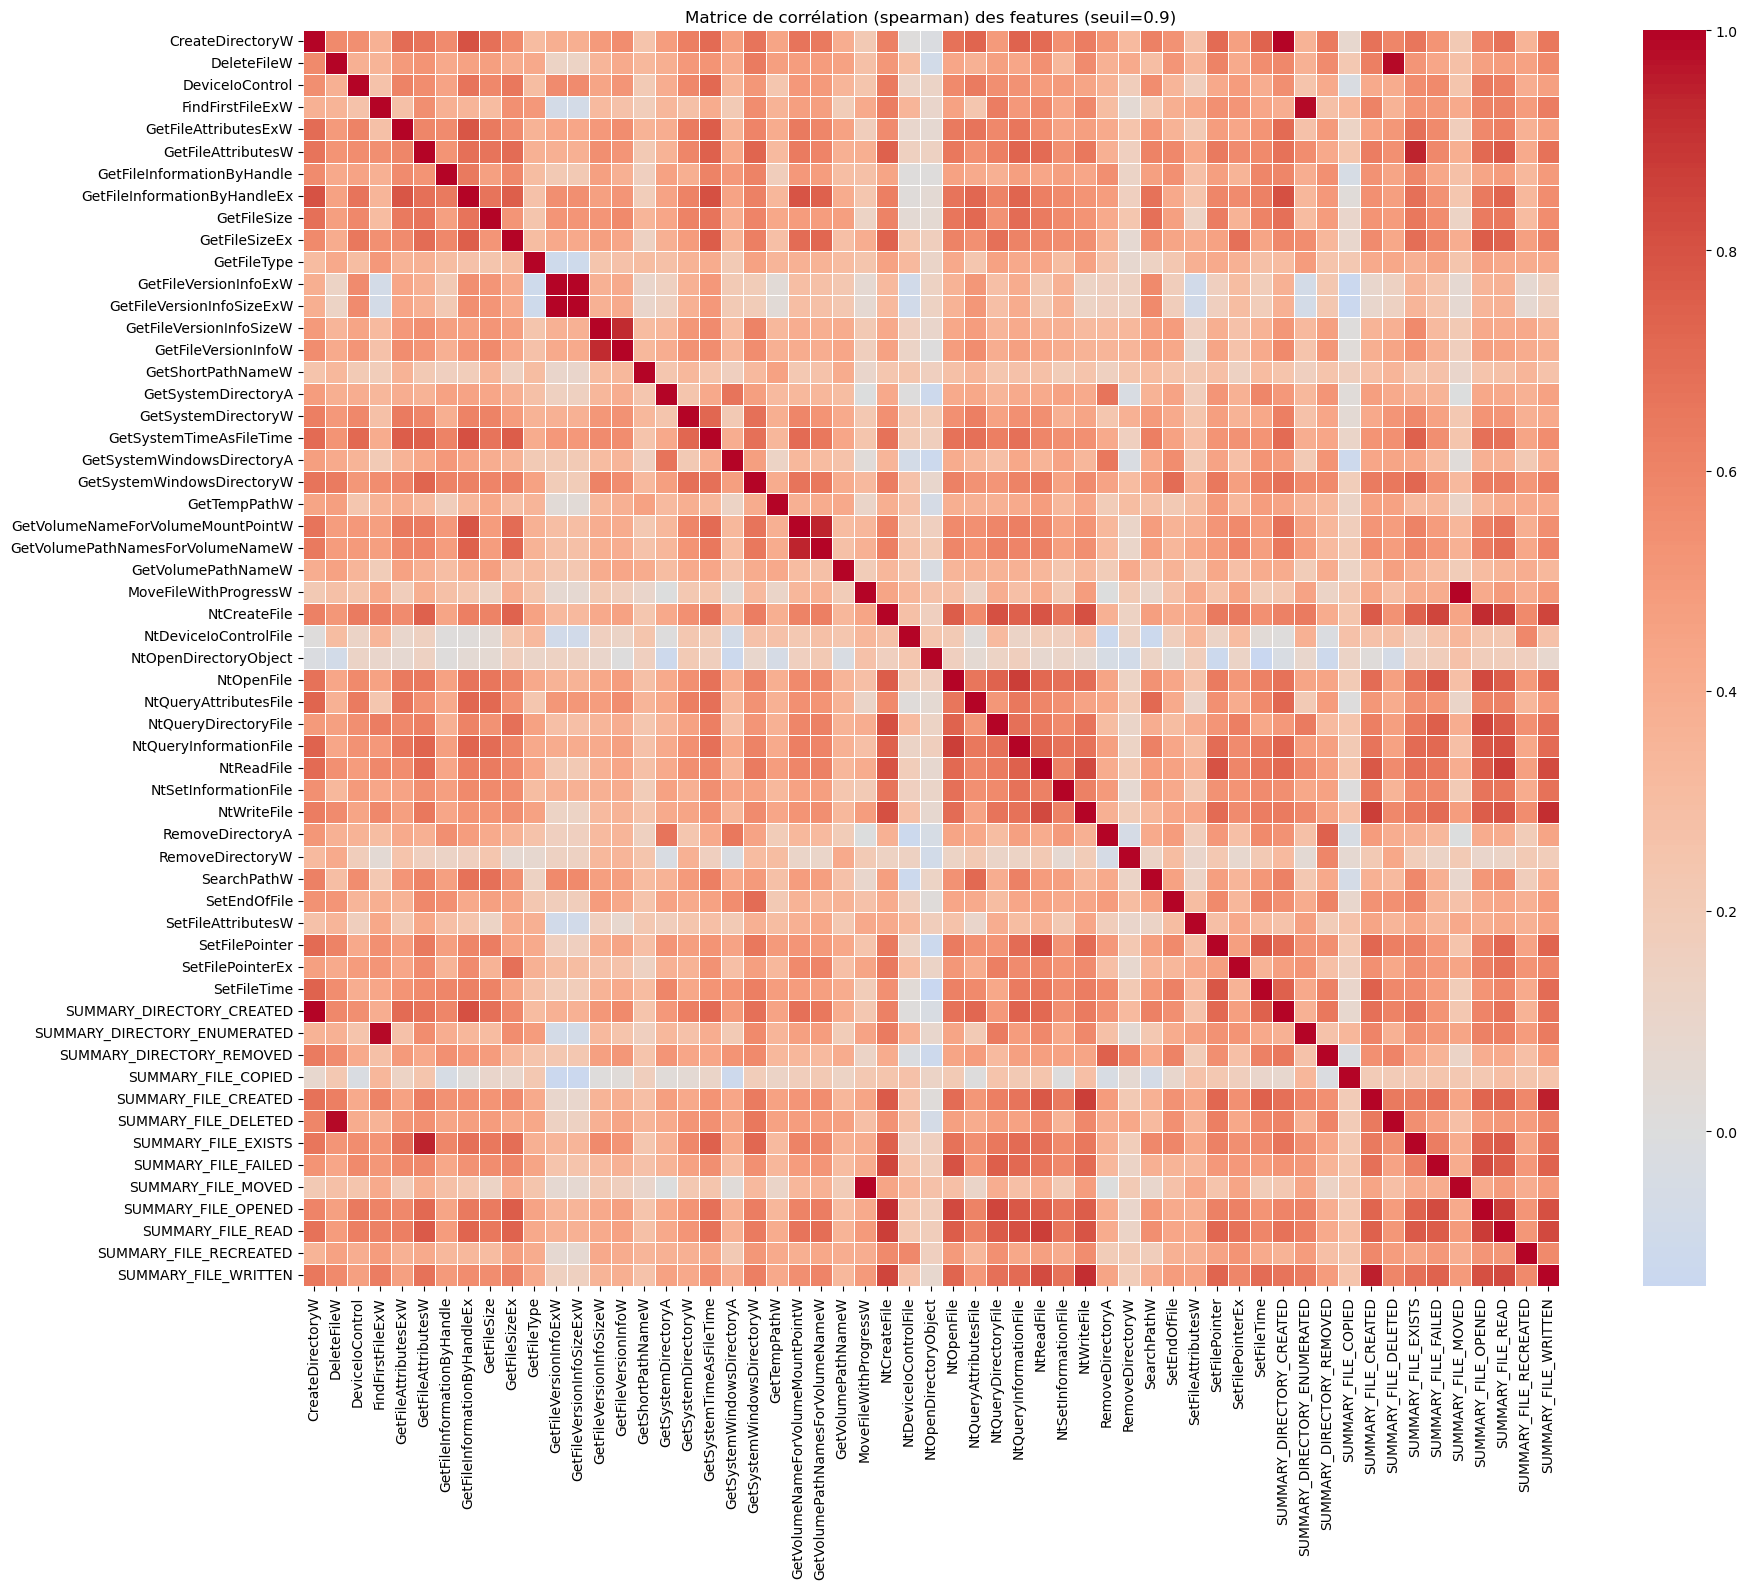

Nombre de paires fortement corrélées : 11
  Paire (GetFileVersionInfoExW / GetFileVersionInfoSizeExW) → garder GetFileVersionInfoExW (0.319), supprimer GetFileVersionInfoSizeExW (0.319)
  Paire (MoveFileWithProgressW / SUMMARY_FILE_MOVED) → garder SUMMARY_FILE_MOVED (0.110), supprimer MoveFileWithProgressW (0.109)
  Paire (CreateDirectoryW / SUMMARY_DIRECTORY_CREATED) → garder SUMMARY_DIRECTORY_CREATED (0.550), supprimer CreateDirectoryW (0.545)
  Paire (DeleteFileW / SUMMARY_FILE_DELETED) → garder SUMMARY_FILE_DELETED (0.268), supprimer DeleteFileW (0.243)
  Paire (FindFirstFileExW / SUMMARY_DIRECTORY_ENUMERATED) → garder SUMMARY_DIRECTORY_ENUMERATED (0.102), supprimer FindFirstFileExW (0.075)
  Paire (SUMMARY_FILE_CREATED / SUMMARY_FILE_WRITTEN) → garder SUMMARY_FILE_CREATED (0.272), supprimer SUMMARY_FILE_WRITTEN (0.210)
  Paire (GetFileAttributesW / SUMMARY_FILE_EXISTS) → garder GetFileAttributesW (0.231), supprimer SUMMARY_FILE_EXISTS (0.212)
  Paire (GetVolumeNameForVolumeMountPo

In [263]:
df_new = supprimer_features_correlees(df_new, method='spearman')
df_new = features_selection(df_new)
X = df_new.drop(columns=['Label'])
y = df_new['Label']

#   Pre-Processing

# Création des train et test sets et verification de la conservation des proportions


In [264]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)


In [265]:
feature_cols = X_train.columns.tolist()

df_original = X_train.copy().reset_index(drop=True)
df_original['Label'] = y_train.values

print(df_original.shape)
pd.DataFrame(df_original).describe()


(411, 28)


,GetFileInformationByHandleEx,GetFileSizeEx,GetFileVersionInfoExW,GetFileVersionInfoW,GetSystemDirectoryA,GetSystemWindowsDirectoryA,GetSystemWindowsDirectoryW,NtCreateFile,NtOpenDirectoryObject,NtQueryAttributesFile,...,SUMMARY_DIRECTORY_CREATED,SUMMARY_DIRECTORY_ENUMERATED,SUMMARY_DIRECTORY_REMOVED,SUMMARY_FILE_CREATED,SUMMARY_FILE_DELETED,SUMMARY_FILE_FAILED,SUMMARY_FILE_MOVED,SUMMARY_FILE_READ,SUMMARY_FILE_RECREATED,Label
count,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,...,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000
mean,15.364964,180.255474,0.737226,2.683698,69.272506,68.433090,111.087591,985.260341,3.615572,78.311436,...,21.817518,272.204380,0.948905,169.866180,31.832117,158.026764,93.683698,160.562044,9.927007,0.464720
std,32.600361,768.265300,2.828263,11.948148,323.263569,323.164667,385.135069,4180.187488,13.253187,435.474723,...,64.904081,1351.638564,4.793778,471.039322,230.698227,1480.630540,442.668964,548.151397,56.244193,0.499362
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,130.000000,0.000000,4.000000,...,1.000000,7.000000,0.000000,2.000000,0.000000,6.000000,0.000000,8.000000,1.000000,0.000000
75%,22.500000,27.000000,0.000000,2.000000,1.000000,0.000000,15.500000,498.000000,1.000000,27.000000,...,9.000000,37.000000,0.500000,36.500000,4.000000,29.500000,0.000000,40.000000,2.000000,1.000000
max,455.000000,7126.000000,16.000000,164.000000,1758.000000,1757.000000,2105.000000,64852.000000,74.000000,7177.000000,...,305.000000,14121.000000,77.000000,2997.000000,2995.000000,29312.000000,3856.000000,3634.000000,673.000000,1.000000


# GENERATION DES DATASETS

In [266]:

TARGET_COLUMN  = 'Label'
N_SYNTHETIC    = 205       
EPOCHS         = 500
OUTPUT_DIR     = './resultats'
os.makedirs(OUTPUT_DIR, exist_ok=True)


feature_cols = [c for c in df_original.columns if c != TARGET_COLUMN]
label_map    = {'Goodware': 0, 'Ransomware': 1}
col_order    = df_original.columns.tolist()
col_dtypes   = df_original.dtypes

print(f"Dataset original : {df_original.shape[0]} lignes × {df_original.shape[1]} colonnes")

# ÉTAPE 2 : CTGAN et TVAE
ALGORITHMS = {
    'CTGAN': CTGANSynthesizer,
    'TVAE' : TVAESynthesizer,
}

best_datasets = {}

for algo_name, SynthClass in ALGORITHMS.items():
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df_original)
    synthesizer = SynthClass(metadata, epochs=EPOCHS, verbose=False)
    synthesizer.fit(df_original)
    df_synthetic = synthesizer.sample(num_rows=N_SYNTHETIC)

    df_synthetic = df_synthetic[[c for c in col_order if c in df_synthetic.columns]]
    for col in col_order:
        if col in df_synthetic.columns:
            try:
                df_synthetic[col] = df_synthetic[col].astype(col_dtypes[col])
            except Exception:
                pass

    df_augmented = pd.concat([df_original, df_synthetic], ignore_index=True)
    best_datasets[algo_name] = df_augmented

    output_path = f'{OUTPUT_DIR}/{algo_name.lower()}_result.csv'
    df_augmented.to_csv(output_path, index=False)
    print(f" Sauvegardé → {output_path}")

# ÉTAPE 3 : TGAN (via SDV GaussianCopulaSynthesizer — backend compatible)
from sdv.single_table import GaussianCopulaSynthesizer

print("  Entraînement TGAN (GaussianCopula)...")
metadata_tgan = SingleTableMetadata()
metadata_tgan.detect_from_dataframe(df_original)
synth_tgan = GaussianCopulaSynthesizer(metadata_tgan)
synth_tgan.fit(df_original)
df_tgan_synth = synth_tgan.sample(num_rows=N_SYNTHETIC)

df_tgan_best = pd.concat([df_original, df_tgan_synth], ignore_index=True)
best_datasets['TGAN'] = df_tgan_best
df_tgan_best.to_csv(f'{OUTPUT_DIR}/tgan_result.csv', index=False)
print(f" Sauvegardé → {OUTPUT_DIR}/tgan_result.csv")

# Récupération
df_ctgan = best_datasets['CTGAN']
df_tgan  = best_datasets['TGAN']
df_tvae  = best_datasets['TVAE']

print("  FICHIERS GÉNÉRÉS")
print(f" {OUTPUT_DIR}/ctgan_result.csv")
print(f" {OUTPUT_DIR}/tgan_result.csv")
print(f" {OUTPUT_DIR}/tvae_result.csv")


Dataset original : 411 lignes × 28 colonnes
 Sauvegardé → ./resultats/ctgan_result.csv
 Sauvegardé → ./resultats/tvae_result.csv
  Entraînement TGAN (GaussianCopula)...
 Sauvegardé → ./resultats/tgan_result.csv
  FICHIERS GÉNÉRÉS
 ./resultats/ctgan_result.csv
 ./resultats/tgan_result.csv
 ./resultats/tvae_result.csv


On a effectué cela pour sélectionner le nombre de lignes qui serait parfait pour maximiser le recall , tout en étant pas trop grand pour avoir un pourcentage de testset proche de 20 %

# Correction des valeures négatives

In [267]:
print("\n CTGAN ")
df_ctgan = corriger_valeurs_negatives(df_ctgan)

print("\n TGAN ")
df_tgan = corriger_valeurs_negatives(df_tgan)

print("\n TVAE ")
df_tvae = corriger_valeurs_negatives(df_tvae)
for nom, df_ds in [('CTGAN', df_ctgan), ('TGAN', df_tgan), ('TVAE', df_tvae)]:
    feat = [c for c in df_ds.columns if c != 'Label']
    assert (df_ds[feat] < 0).sum().sum() == 0, f"{nom} contient encore des négatifs !"
print("\n Tous les datasets sont propres (0 valeur négative)")


 CTGAN 

 TGAN 

 TVAE 

 Tous les datasets sont propres (0 valeur négative)


# Normalisation Z-score des données 

In [268]:
scaler = StandardScaler()
 
feature_cols = [c for c in df_original.columns if c != TARGET_COLUMN]
 

scaler.fit(df_original[feature_cols])

 
def normaliser_dataset(df_ds, scaler, feature_cols, target_col=TARGET_COLUMN):
   
    df_norm = df_ds.copy()
    df_norm[feature_cols] = scaler.transform(df_ds[feature_cols])
    return df_norm
 
df_original_norm = normaliser_dataset(df_original, scaler, feature_cols)
df_ctgan_norm    = normaliser_dataset(df_ctgan,    scaler, feature_cols)
df_tgan_norm     = normaliser_dataset(df_tgan,     scaler, feature_cols)
df_tvae_norm     = normaliser_dataset(df_tvae,     scaler, feature_cols)

X_test_norm = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)
 
print("Normalisation appliquée sur tous les datasets.")


Normalisation appliquée sur tous les datasets.


# Vérification de la conservation de l'équilibre du dataset après génération


  Original (411 lignes) —  équilibré (écart = 7.1 pts)
                  0 :   220 lignes  (53.5 %)
                  1 :   191 lignes  (46.5 %)

  CTGAN (616 lignes) —   déséquilibré (écart = 13.3 pts)
                  0 :   349 lignes  (56.7 %)
                  1 :   267 lignes  (43.3 %)

  TGAN (616 lignes) —  équilibré (écart = 4.5 pts)
                  0 :   322 lignes  (52.3 %)
                  1 :   294 lignes  (47.7 %)

  TVAE (616 lignes) —  équilibré (écart = 5.5 pts)
                  0 :   325 lignes  (52.8 %)
                  1 :   291 lignes  (47.2 %)



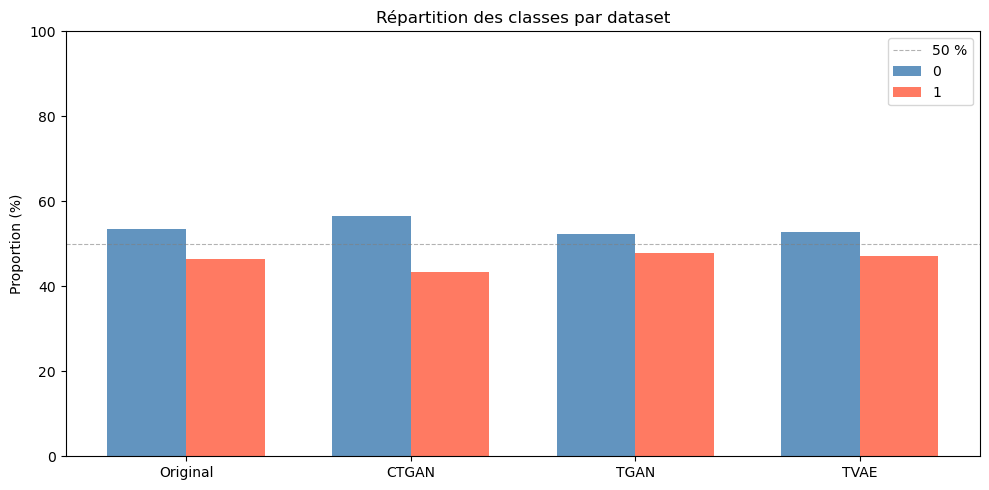

In [269]:
datasets_a_verifier = {
    'Original' : df_original_norm,
    'CTGAN'    : df_ctgan_norm,
    'TGAN'     : df_tgan_norm,
    'TVAE'     : df_tvae_norm,
}
 
equilibre_df = verifier_equilibre(datasets_a_verifier, target_col='Label')

# Validation qualité des données synthétiques — Test de Kolmogorov-Smirnov

Test KS sur 27 features — seuil α=0.05

  CTGAN    → 15/27 features similaires (55.6% conservées)
  TGAN     → 7/27 features similaires (25.9% conservées)
  TVAE     → 21/27 features similaires (77.8% conservées)


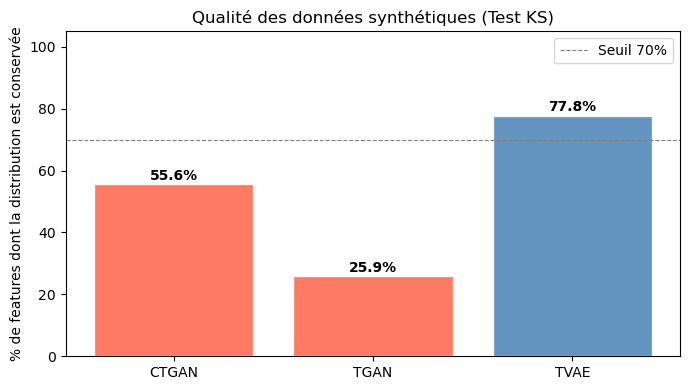

In [270]:
def comparer_distributions_ks(df_reel, datasets_synthetiques: dict, target_col='Label', alpha=0.05):
    feature_cols = [c for c in df_reel.columns if c != target_col]
    n_features = len(feature_cols)

    print(f"Test KS sur {n_features} features — seuil α={alpha}\n")

    summary = {}
    for ds_name, df_syn in datasets_synthetiques.items():
        rejets = 0
        stats_list = []
        for col in feature_cols:
            if col not in df_syn.columns:
                continue
            stat, p = ks_2samp(df_reel[col].dropna(), df_syn[col].dropna())
            rejet = p < alpha
            if rejet:
                rejets += 1
            stats_list.append({'feature': col, 'ks_stat': round(stat, 4), 'p_value': round(p, 6), 'rejet_H0': rejet})

        pct_ok = round(100 * (1 - rejets / n_features), 1)
        summary[ds_name] = {'rejets': rejets, 'pct_similaire': pct_ok, 'detail': stats_list}
        print(f"  {ds_name:8s} → {n_features - rejets}/{n_features} features similaires ({pct_ok}% conservées)")

    # Graphique : % de features dont la distribution est conservée
    labels = list(summary.keys())
    scores = [summary[k]['pct_similaire'] for k in labels]
    colors_bar = ['steelblue' if s >= 70 else 'tomato' for s in scores]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, scores, color=colors_bar, alpha=0.85, edgecolor='white')
    ax.axhline(70, color='gray', linestyle='--', linewidth=0.8, label='Seuil 70%')
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{score}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_ylabel("% de features dont la distribution est conservée")
    ax.set_title("Qualité des données synthétiques (Test KS)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return summary

datasets_synthetiques_norm = {
    'CTGAN': df_ctgan_norm,
    'TGAN' : df_tgan_norm,
    'TVAE' : df_tvae_norm,
}
 
ks_summary = comparer_distributions_ks(df_original_norm, datasets_synthetiques_norm, target_col='Label')


In [271]:
import pandas as pd
ctgan_data = pd.read_csv(r'./resultats/ctgan_result.csv')
df_ctgan = pd.DataFrame(ctgan_data)
tvae_data = pd.read_csv(r'./resultats/tvae_result.csv')
df_tvae = pd.DataFrame(tvae_data)

# Evaluation de chaque dataset sur plusieurs modèle de ML et DL

In [272]:
label_mapping = {'Goodware': 0, 'Ransomware': 1}

# Vérifie que y_test est défini, sinon le reconstruit depuis df_original
if 'y_test' not in dir() or y_test is None:
    from sklearn.model_selection import train_test_split
    X = df_original.drop(columns=['Label'])
    y = df_original['Label']
    _, X_test, _, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    y_test = y_test.reset_index(drop=True)

# Encodage des labels textuels en entiers (si nécessaire)
if y_test.dtype == object:
    y_test_enc = y_test.map(label_mapping)
else:
    y_test_enc = y_test

print('y_test_enc dtype:', y_test_enc.dtype)
print('Valeurs uniques:', y_test_enc.unique())


In [273]:
print("y_test brut :", y_test.unique())
print("dtype :", y_test.dtype)

y_test brut : [0 1]
dtype : int64


In [278]:
print(pd.Series(y_test_enc).isna().sum())   # doit afficher 0
print(np.unique(y_test_enc))                # doit afficher [0 1]

177
[nan]


In [277]:
def split_xy(df, target_col='Label'):
    X = df.drop(columns=[target_col]).values.astype(np.float32)
    y = df[target_col].values.astype(int)
    return X, y


def compute_metrics(y_true, y_pred, y_proba=None):
    classes = np.unique(y_true)
    is_binary = set(classes) <= {0, 1}
    avg = 'binary' if is_binary else 'weighted'
    pl  = 1        if is_binary else None

    return {
        'Accuracy' : round(accuracy_score (y_true, y_pred), 4),
        'Recall'   : round(recall_score   (y_true, y_pred, pos_label=pl, average=avg, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, pos_label=pl, average=avg, zero_division=0), 4),
        'F1-score' : round(f1_score       (y_true, y_pred, pos_label=pl, average=avg, zero_division=0), 4),
        'AUC'      : round(roc_auc_score  (y_true, y_proba), 4) if y_proba is not None else np.nan,
    }


def run_svm(X_train, y_train, X_test, y_test):
    clf = SVC(kernel='rbf', C=1.0, gamma='scale',
              class_weight='balanced', probability=True, random_state=42)
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_pred, y_proba)


def run_knn(X_train, y_train, X_test, y_test):
    clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_pred, y_proba)


def run_mlp(X_train, y_train, X_test, y_test):
    clf = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_pred, y_proba)


def build_cnn(input_dim):
    model = Sequential([
        Reshape((input_dim, 1), input_shape=(input_dim,)),
        Conv1D(64,  kernel_size=3, activation='relu', padding='same'),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64,  activation='relu'),
        Dropout(0.2),
        Dense(1,   activation='sigmoid'),
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


def run_cnn(X_train, y_train, X_test, y_test):
    X_train = X_train.astype(np.float32)
    X_test  = X_test.astype(np.float32)
    model   = build_cnn(X_train.shape[1])
    es      = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train, y_train,
              epochs=50,
              batch_size=32,
              validation_split=0.1,
              callbacks=[es],
              verbose=0)
    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)
    return compute_metrics(y_test, y_pred, y_proba)


def benchmark(datasets, X_test, y_test, target_col='Label'):
    y_te = np.array(y_test, dtype=float)   # float d'abord pour détecter les NaN
    X_te = np.array(X_test, dtype=np.float32)

    # Supprimer les lignes avec NaN/inf dans X ou y
    nan_mask = np.isfinite(X_te).all(axis=1) & np.isfinite(y_te)
    if not nan_mask.all():
        print(f"⚠️  {(~nan_mask).sum()} lignes invalides (NaN/inf) supprimées")
        X_te = X_te[nan_mask]
        y_te = y_te[nan_mask]

    y_te = y_te.astype(int).flatten()   # cast en int seulement après nettoyage

    print(f"X_te : {X_te.shape}, y_te : {y_te.shape}, classes : {np.unique(y_te)}")

    models = {
        'Kernel SVM' : run_svm,
        'KNN'        : run_knn,
        'MLP'        : run_mlp,
        'CNN'        : run_cnn,
    }

    records = []
    for ds_name, df in datasets.items():
        X_tr, y_tr = split_xy(df, target_col)
        for model_name, run_fn in models.items():
            print(f"  {model_name:15s} | dataset : {ds_name} ...", end=' ', flush=True)
            metrics = run_fn(X_tr, y_tr, X_te, y_te)
            print("OK")
            records.append({'Dataset': ds_name, 'Model': model_name, **metrics})

    results = pd.DataFrame(records).set_index(['Model', 'Dataset'])
    return results


datasets = {
    'Original' : df_original_norm,
    'CTGAN'    : df_ctgan_norm,
    'TGAN'     : df_tgan_norm,
    'TVAE'     : df_tvae_norm,
}

results = benchmark(datasets, X_test_norm, y_test_enc, target_col='Label')
metrics_cols = ['Accuracy', 'Recall', 'Precision', 'F1-score', 'AUC']


def print_table(df_subset, dataset_name):
    col_width = 10
    header = f"{'Modèle':<20}" + "".join(f"{m:>{col_width}}" for m in metrics_cols)
    sep    = "─" * len(header)

    print(f"\n Dataset : {dataset_name}")
    print(sep)
    print(header)
    print(sep)

    for model_name, row in df_subset.iterrows():
        line = f"{model_name:<20}" + "".join(f"{row[m]:>{col_width}.4f}" for m in metrics_cols)
        print(line)

    best_idx = df_subset['F1-score'].idxmax()
    print(sep)


for ds_name in datasets.keys():
    subset = results.xs(ds_name, level='Dataset')
    print_table(subset, ds_name)


# ── Calcul de la largeur de séparateur ici, en dehors de print_table ──
col_width = 10
header_len = len(f"{'Modèle':<20}" + "".join(f"{m:>{col_width}}" for m in metrics_cols))
sep = "─" * header_len

print("\n Meilleurs résultats globaux par métrique :")
print(sep)
for metric in metrics_cols:
    idx = results[metric].idxmax()
    val = results[metric].max()
    print(f"  {metric:<12} {idx[0]:<18} {idx[1]:<12} {val:>8.4f}")
print(sep)

X_te : (177, 27), y_te : (177,), classes : [-9223372036854775808]
  Kernel SVM      | dataset : Original ... 

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

# Tableau récapitulatif comparatif — Heatmap des métriques

In [ ]:
def plot_heatmap_resultats(results_df, metrics_cols):
    datasets_list = results_df.index.get_level_values('Dataset').unique().tolist()
    models_list   = results_df.index.get_level_values('Model').unique().tolist()  # ← 'Model' sans accent

    for metric in metrics_cols:
        mat = pd.DataFrame(index=models_list, columns=datasets_list, dtype=float)
        for model in models_list:
            for ds in datasets_list:
                try:
                    mat.loc[model, ds] = results_df.loc[(model, ds), metric]
                except KeyError:
                    mat.loc[model, ds] = np.nan

        fig, ax = plt.subplots(figsize=(8, 4))
        sns.heatmap(mat.astype(float), annot=True, fmt='.4f', cmap='YlGn',
                    linewidths=0.5, ax=ax, vmin=0, vmax=1,
                    annot_kws={'size': 10})
        ax.set_title(f"Métrique : {metric}", fontsize=13, fontweight='bold')
        ax.set_xlabel("Dataset")
        ax.set_ylabel("Modèle")
        plt.tight_layout()
        plt.show()

plot_heatmap_resultats(results, metrics_cols)